# [SM-TCSR 실습 05] 우측 중도절단과 Truncated IPCW 꼬리 재정규화

> **학습 목표**: 
> 1. 중도절단 시점 $C_i$에서 과거 질량을 0으로 제거하고 미래 꼬리를 재정규화하는 하드 제약 연산을 실습합니다.
> 2. Truncated IPCW 가중치 적용 전후의 생존 곡선 편향 교정을 확인합니다.


In [1]:
import sys, os
ROOT_DIR = os.path.abspath("..")
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.operators.survtd_operator import truncated_censoring_target

K = 30
delta_s = 1.0
bins = np.arange(K) * delta_s

# 타깃망의 잔여 수명 예측 분포 (평균 15시간 지능형 예측)
p_target_last = torch.exp(-0.5 * ((torch.arange(K).float() - 15.0) / 4.0) ** 2)
p_target_last = p_target_last / p_target_last.sum()

# 환자가 8시간 시점에서 퇴원(Censored)함!
censoring_residual = 8.0

# 하드 생존 제약 및 꼬리 재정규화 수행
p_censored_target = truncated_censoring_target(
    p_target_last, censoring_residual=censoring_residual, delta_s=delta_s, K=K
)

print(f"원래 타깃 합: {p_target_last.sum().item():.4f}")
print(f"중도절단 보정 후 타깃 합: {p_censored_target.sum().item():.4f}")
print(f"절단 시점(s <= 8h) 잔여 질량: {p_censored_target[:8].sum().item():.6f} (완벽히 0으로 소거!)")


원래 타깃 합: 1.0000
중도절단 보정 후 타깃 합: 1.0000
절단 시점(s <= 8h) 잔여 질량: 0.000000 (완벽히 0으로 소거!)


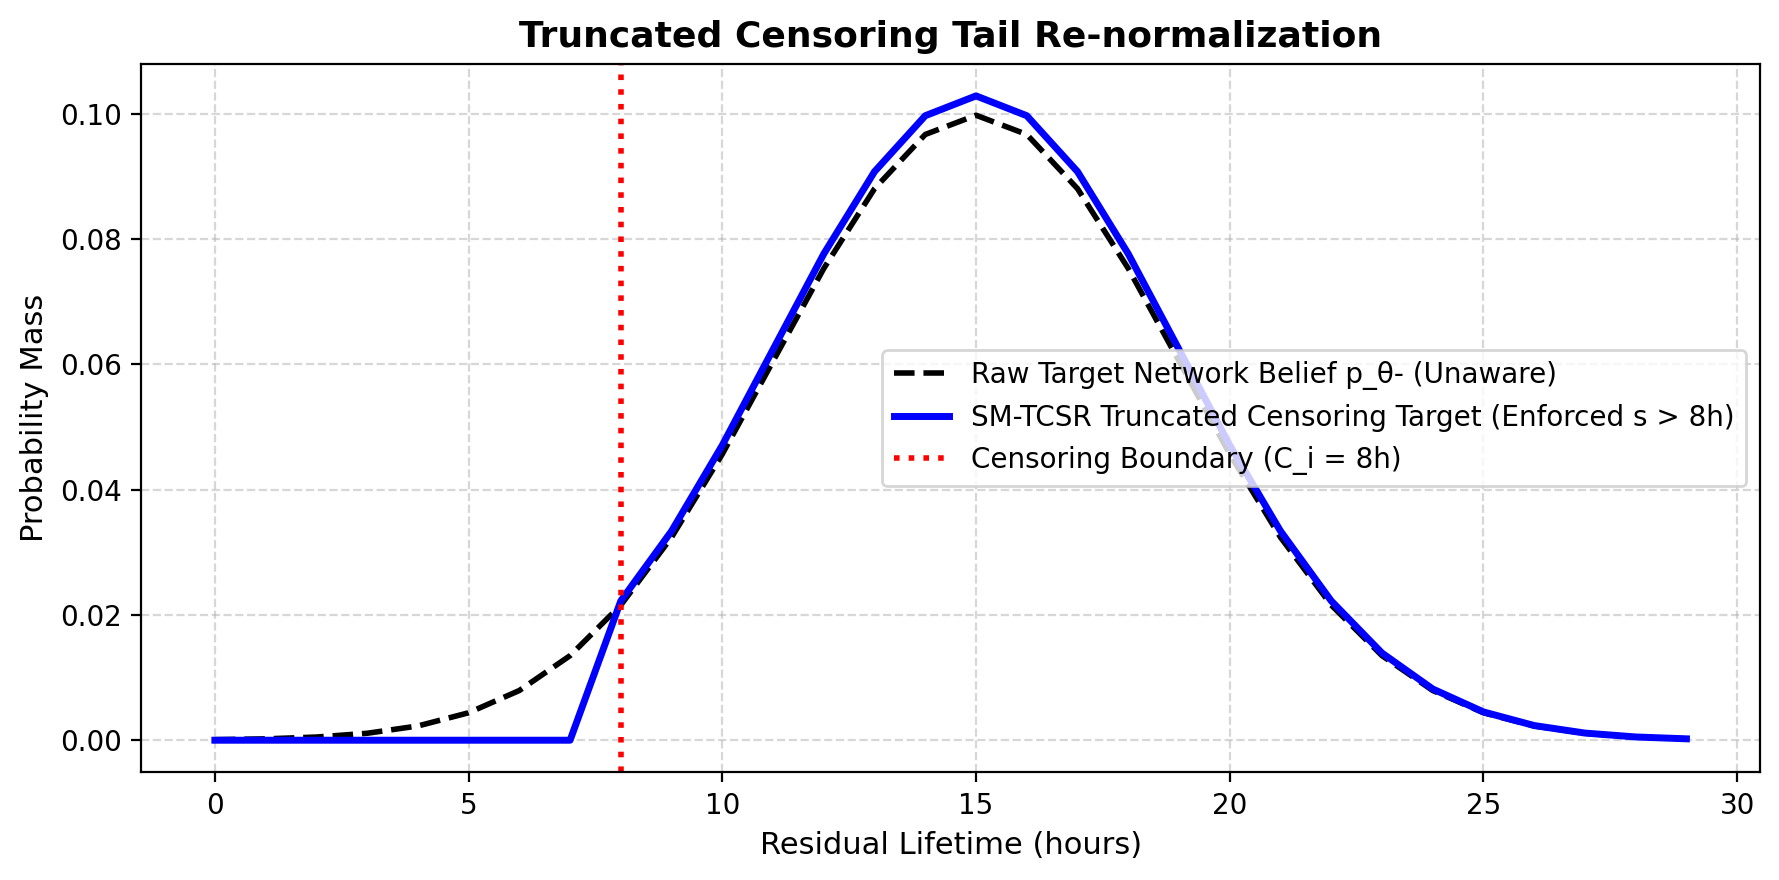

In [2]:
plt.figure(figsize=(9, 4.5), dpi=200)

plt.plot(bins, p_target_last.numpy(), 'k--', label='Raw Target Network Belief p_θ- (Unaware)', lw=2)
plt.plot(bins, p_censored_target.numpy(), 'b-', label='SM-TCSR Truncated Censoring Target (Enforced s > 8h)', lw=2.5)
plt.axvline(x=censoring_residual, color='r', linestyle=':', lw=2, label='Censoring Boundary (C_i = 8h)')

plt.title("Truncated Censoring Tail Re-normalization", fontsize=13, fontweight='bold')
plt.xlabel("Residual Lifetime (hours)", fontsize=11)
plt.ylabel("Probability Mass", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
